In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from mne.datasets import eegbci

subject = 1
runs = [6]  # motor imagery run
files = eegbci.load_data(subject, runs)
files

Using default location ~/mne_data for EEGBCI...
Creating /Users/bogdanuserenko/mne_data


Do you want to set the path:
    /Users/bogdanuserenko/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n?  y


Attempting to create new mne-python configuration file:
/Users/bogdanuserenko/.mne/mne-python.json
Could not read the /Users/bogdanuserenko/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m01s (2.5 MB)


[PosixPath('/Users/bogdanuserenko/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf')]

In [3]:
raw = mne.io.read_raw_edf(files[0], preload=True)
raw

Extracting EDF parameters from /Users/bogdanuserenko/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


<RawEDF | S001R06.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

In [4]:
raw.ch_names[:10]

['Fc5.',
 'Fc3.',
 'Fc1.',
 'Fcz.',
 'Fc2.',
 'Fc4.',
 'Fc6.',
 'C5..',
 'C3..',
 'C1..']

In [5]:
print(raw.info)

<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


Using matplotlib as 2D backend.


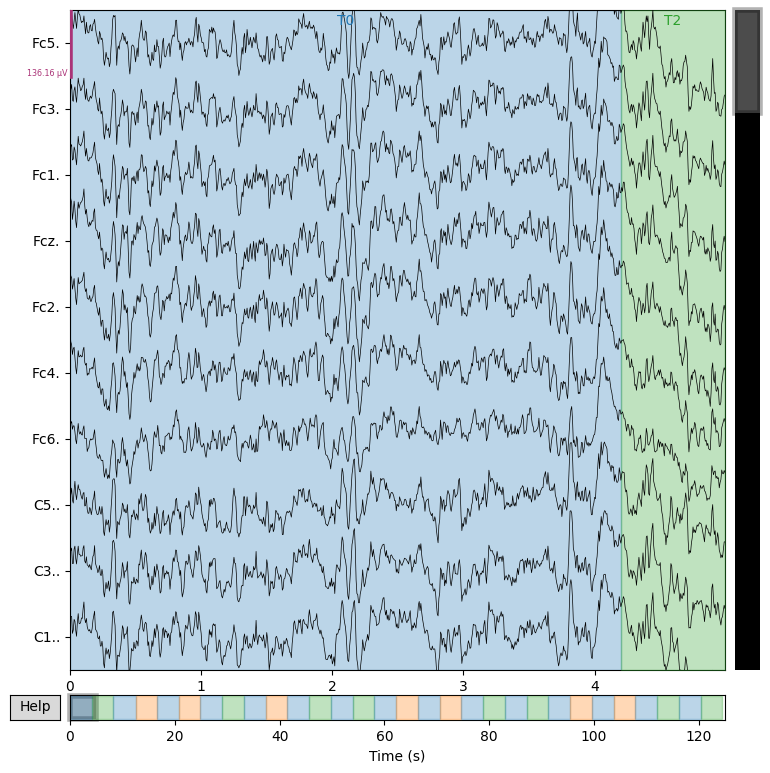

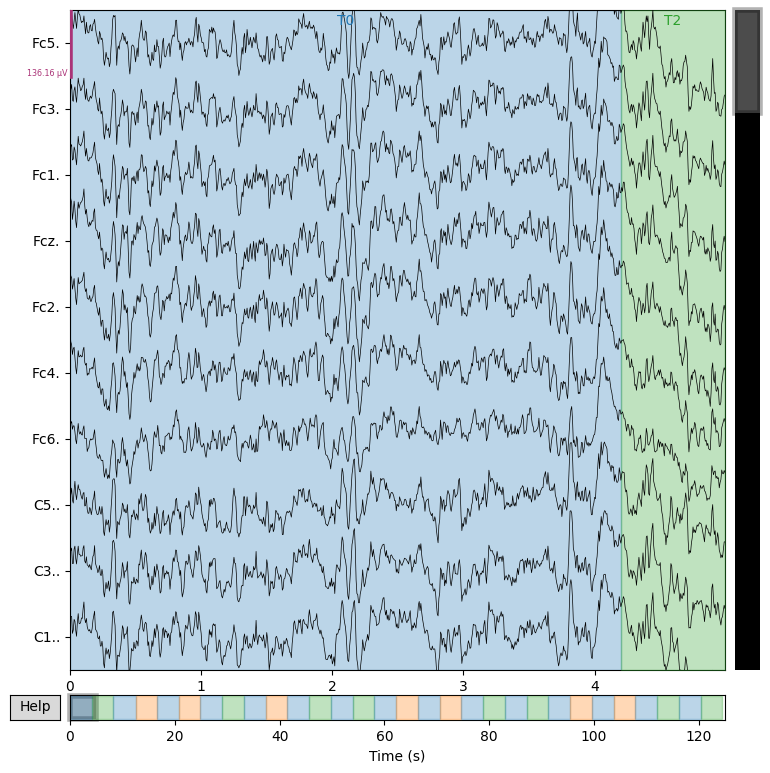

In [6]:
raw.plot(duration=5, n_channels=10, scalings="auto")

In [7]:
data = raw.get_data()
data.shape

(64, 20000)

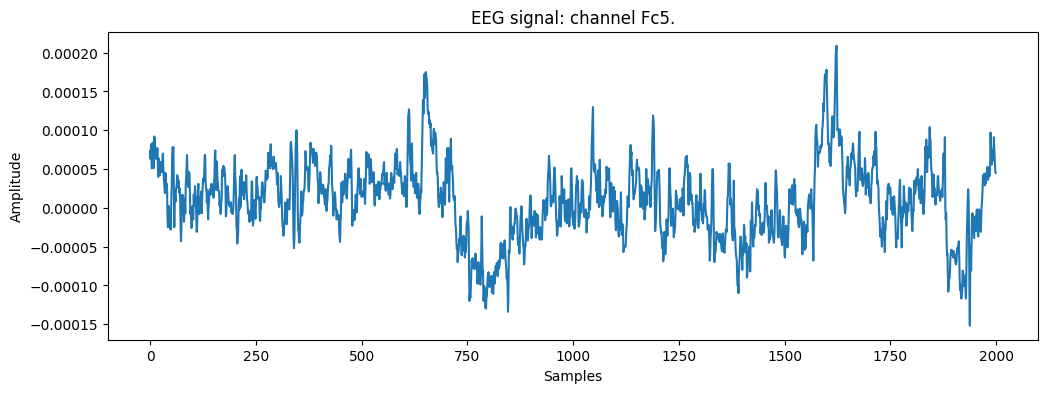

In [8]:
channel_idx = 0
signal = data[channel_idx]

plt.figure(figsize=(12, 4))
plt.plot(signal[:2000])
plt.title(f"EEG signal: channel {raw.ch_names[channel_idx]}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

In [9]:
events, event_id = mne.events_from_annotations(raw)

print(events[:10])
print(event_id)

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
[[   0    0    1]
 [ 672    0    3]
 [1328    0    1]
 [2000    0    2]
 [2656    0    1]
 [3328    0    2]
 [3984    0    1]
 [4656    0    3]
 [5312    0    1]
 [5984    0    2]]
{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}


In [10]:
tmin = -1.0   # 1 сек ДО события
tmax = 4.0    # 4 сек ПОСЛЕ

epochs = mne.Epochs(raw, events, event_id, tmin, tmax, preload=True)

epochs

Not setting metadata
30 matching events found
Setting baseline interval to [-1.0, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 30 events and 801 original time points ...
1 bad epochs dropped


<Epochs | 29 events (all good), -1 – 4 s (baseline -1 – 0 s), ~11.4 MiB, data loaded,
 np.str_('T0'): 14
 np.str_('T1'): 7
 np.str_('T2'): 8>

In [11]:
epochs_data = epochs.get_data()
epochs_data.shape

(29, 64, 801)

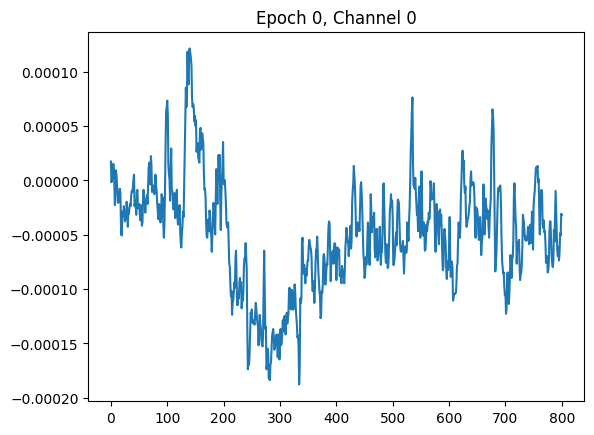

In [12]:
plt.plot(epochs_data[0][0])
plt.title("Epoch 0, Channel 0")
plt.show()

In [13]:
event_id

{np.str_('T0'): 1, np.str_('T1'): 2, np.str_('T2'): 3}

In [14]:
epochs_data.shape

(29, 64, 801)

In [15]:
import numpy as np

# сохранить X
np.save("../data/X.npy", epochs_data)

# сохранить events (метки)
np.save("../data/events.npy", events)

FileNotFoundError: [Errno 2] No such file or directory: '../data/X.npy'

In [16]:
import numpy as np

np.save("../data/X.npy", epochs_data)

np.save("../data/events.npy", events)

FileNotFoundError: [Errno 2] No such file or directory: '../data/X.npy'

In [17]:
import os

os.makedirs("../data", exist_ok=True)

In [19]:
import numpy as np

# сохранить X
np.save("../data/X.npy", epochs_data)

# сохранить events (метки)
np.save("../data/events.npy", events)

In [20]:
import os
import numpy as np

# создать папку
os.makedirs("../data", exist_ok=True)

# сохранить данные
np.save("../data/X.npy", epochs_data)
np.save("../data/events.npy", events)

labels = epochs.events[:, -1]
np.save("../data/y.npy", labels)

In [21]:
os.listdir("../data")

['X.npy', 'y.npy', 'events.npy']

In [22]:
labels = epochs.events[:, -1]
np.save("../data/y.npy", labels)